# Análise Exploratória — Tweets da Invasão aos 3 Poderes

Objetivo: carregar todos os CSVs do dataset, filtrar apenas os tweets originais (sem `referenced_tweets`) e exportar para `original_tweets.csv`.

In [2]:
import pandas as pd
import glob
import os

csv_files = sorted(glob.glob("dataset/invasao-3-poderes/*.csv"))
print(f"Arquivos encontrados: {len(csv_files)}")
for f in csv_files:
    print(f"  - {os.path.basename(f)}")

Arquivos encontrados: 7
  - 0801_invasao-06hr-09hr.csv
  - 0801_invasao-09hr-12hr.csv
  - 0801_invasao-12hr-15hr.csv
  - 0801_invasao-15hr-18hr.csv
  - 0801_invasao-18hr-21hr.csv
  - 0801_invasao-21hr-01hr.csv
  - 0901_invasao-01hr-06hr.csv


In [3]:
df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
print(f"Total de tweets carregados: {len(df)}")
print(f"\nColunas: {list(df.columns)}")
df.head()

Total de tweets carregados: 1235087

Colunas: ['conversation_id', 'Created_at_convert', 'author_id', 'referenced_tweets']


,conversation_id,Created_at_convert,author_id,referenced_tweets
0,1265044941765566470,2023-01-08 07:13:08-03:00,33437788,[<ReferencedTweet id=1265044941765566470 type=...
1,1576760910932193281,2023-01-08 08:52:35-03:00,205756718,[<ReferencedTweet id=1576760910932193281 type=...
2,1587236013965025281,2023-01-08 08:44:22-03:00,1598260624261357568,[<ReferencedTweet id=1587236013965025281 type=...
3,1605684489887174657,2023-01-08 08:30:39-03:00,1605259536100630530,[<ReferencedTweet id=1605684489887174657 type=...
4,1607733117560754178,2023-01-08 08:55:25-03:00,1591921412985470976,[<ReferencedTweet id=1612000358670209025 type=...


## Distribuição de tipos de tweet

In [4]:
is_original = df["referenced_tweets"].isna()

print(f"Tweets originais (sem referenced_tweets): {is_original.sum()}")
print(f"Tweets com referenced_tweets (reply, retweet, etc.): {(~is_original).sum()}")
print(f"\nProporção de originais: {is_original.mean():.2%}")

Tweets originais (sem referenced_tweets): 101600
Tweets com referenced_tweets (reply, retweet, etc.): 1133487

Proporção de originais: 8.23%


In [5]:
# Contagem por tipo de referenced_tweet (para os não-originais)
df.loc[~is_original, "referenced_tweets"].str.extract(r"type=(\w+)")[0].value_counts()

0
retweeted     1100026
replied_to      20870
quoted          12591
Name: count, dtype: int64

## Filtragem e análise dos tweets originais

In [6]:
original_tweets = df[is_original].drop(columns=["referenced_tweets"]).copy()
original_tweets["Created_at_convert"] = pd.to_datetime(original_tweets["Created_at_convert"])

print(f"Total de tweets originais: {len(original_tweets)}")
print(f"Autores únicos: {original_tweets['author_id'].nunique()}")
print(f"Período: {original_tweets['Created_at_convert'].min()} a {original_tweets['Created_at_convert'].max()}")
original_tweets.head()

Total de tweets originais: 101600
Autores únicos: 74654
Período: 2023-01-08 06:00:12-03:00 a 2023-01-09 05:59:44-03:00


,conversation_id,Created_at_convert,author_id
298,1612011275860467712,2023-01-08 06:00:12-03:00,1370370671684026368
321,1612011457750892544,2023-01-08 06:00:55-03:00,1606772966552997889
351,1612011805026537472,2023-01-08 06:02:18-03:00,1565390228138983425
397,1612012335274823682,2023-01-08 06:04:25-03:00,1596433299706191872
404,1612012389918015488,2023-01-08 06:04:38-03:00,166836850


<Axes: title={'center': 'Tweets originais por hora'}, xlabel='Created_at_convert', ylabel='Quantidade'>

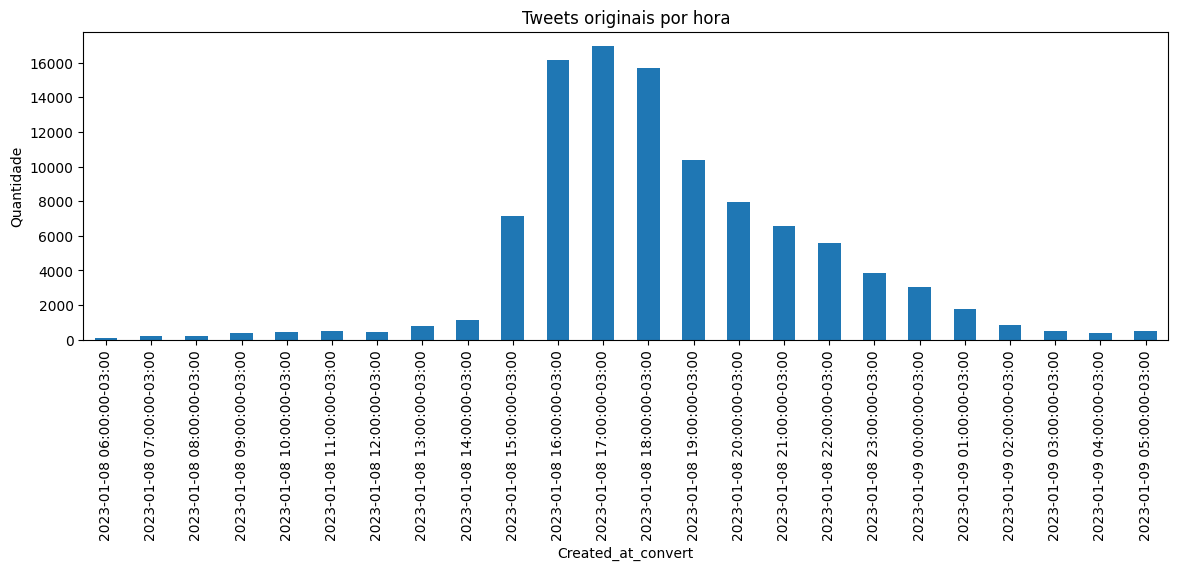

In [7]:
# Distribuição temporal dos tweets originais por hora
original_tweets.set_index("Created_at_convert").resample("1h").size().plot(
    kind="bar", figsize=(14, 4), title="Tweets originais por hora", ylabel="Quantidade"
)

<Axes: title={'center': 'Top 10 autores — tweets originais'}, xlabel='Quantidade', ylabel='author_id'>

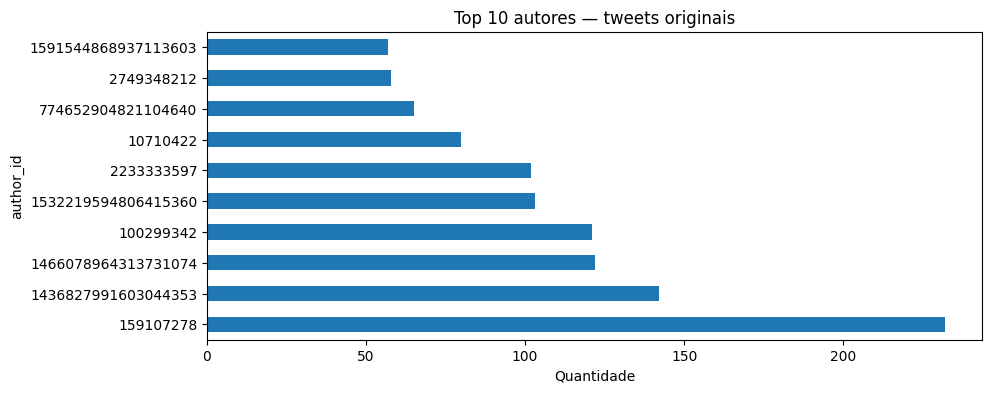

In [8]:
# Top 10 autores com mais tweets originais
original_tweets["author_id"].value_counts().head(10).plot(
    kind="barh", figsize=(10, 4), title="Top 10 autores — tweets originais", xlabel="Quantidade"
)

## Exportação

In [9]:
output_path = "original_tweets.csv"
original_tweets.to_csv(output_path, index=False)
print(f"Exportado {len(original_tweets)} tweets originais para '{output_path}'")

Exportado 101600 tweets originais para 'original_tweets.csv'


## Análise de retweets — quais originais foram mais retweetados?

O dataset tem 1.100.026 retweets. Cada retweet referencia o `id` do tweet original no campo `referenced_tweets`. Vamos extrair esses IDs, contar quantas vezes cada original foi retweetado **dentro do dataset**, e cruzar com nossos tweets originais.

In [10]:
# Extrair o ID do tweet original referenciado em cada retweet
retweets = df[df["referenced_tweets"].str.contains("retweeted", na=False)].copy()
retweets["retweeted_id"] = retweets["referenced_tweets"].str.extract(r"id=(\d+)\s+type=retweeted")

print(f"Total de retweets no dataset: {len(retweets):,}")
print(f"Tweets originais distintos retweetados: {retweets['retweeted_id'].nunique():,}")

# Contar quantas vezes cada original foi retweetado dentro do dataset
retweet_counts = retweets["retweeted_id"].value_counts().reset_index()
retweet_counts.columns = ["conversation_id", "retweet_count_dataset"]
retweet_counts["conversation_id"] = retweet_counts["conversation_id"].astype(str)

retweet_counts.head(10)

KeyboardInterrupt: 

In [ ]:
# Cruzar com os tweets originais do nosso dataset
original_tweets["conversation_id"] = original_tweets["conversation_id"].astype(str)
top_retweeted = original_tweets.merge(retweet_counts, on="conversation_id", how="left")
top_retweeted["retweet_count_dataset"] = top_retweeted["retweet_count_dataset"].fillna(0).astype(int)

# Ordenar pelos mais retweetados
top_retweeted = top_retweeted.sort_values("retweet_count_dataset", ascending=False).reset_index(drop=True)

print(f"Originais com pelo menos 1 RT no dataset: {(top_retweeted['retweet_count_dataset'] > 0).sum():,}")
print(f"Originais sem nenhum RT no dataset: {(top_retweeted['retweet_count_dataset'] == 0).sum():,}")

top100 = top_retweeted.head(100)
print(f"\n--- Top 100 tweets mais retweetados ---")
print(f"Autores unicos no top 100: {top100['author_id'].nunique()}")
print(f"RTs somados (top 100): {top100['retweet_count_dataset'].sum():,}")
print(f"Menor RT count no top 100: {top100['retweet_count_dataset'].iloc[-1]:,}")
top100[["conversation_id", "author_id", "retweet_count_dataset", "Created_at_convert"]].head(20)

Originais com pelo menos 1 RT no dataset: 19,603
Originais sem nenhum RT no dataset: 81,997

--- Top 100 tweets mais retweetados ---
Autores unicos no top 100: 88
RTs somados (top 100): 145,364
Menor RT count no top 100: 616


,conversation_id,author_id,retweet_count_dataset,Created_at_convert
0,1612035570494054401,749082795662868481,5898,2023-01-08 07:36:44-03:00
1,1612212432339931141,1611047672705581063,4959,2023-01-08 19:19:31-03:00
2,1612223971528777731,159107278,4791,2023-01-08 20:05:23-03:00
3,1612192408703320071,1053378751189397504,4483,2023-01-08 17:59:57-03:00
4,1612198695876927488,65897788,3982,2023-01-08 18:24:56-03:00
5,1612180212241895425,64068459,3923,2023-01-08 17:11:30-03:00
6,1612160681310134272,60640635,3389,2023-01-08 15:53:53-03:00
7,1612207574715088904,838392489434361856,3202,2023-01-08 19:00:13-03:00
8,1612146256520019968,953378142198161409,3057,2023-01-08 14:56:34-03:00
9,1612213585999953920,3377844586,3002,2023-01-08 19:24:07-03:00


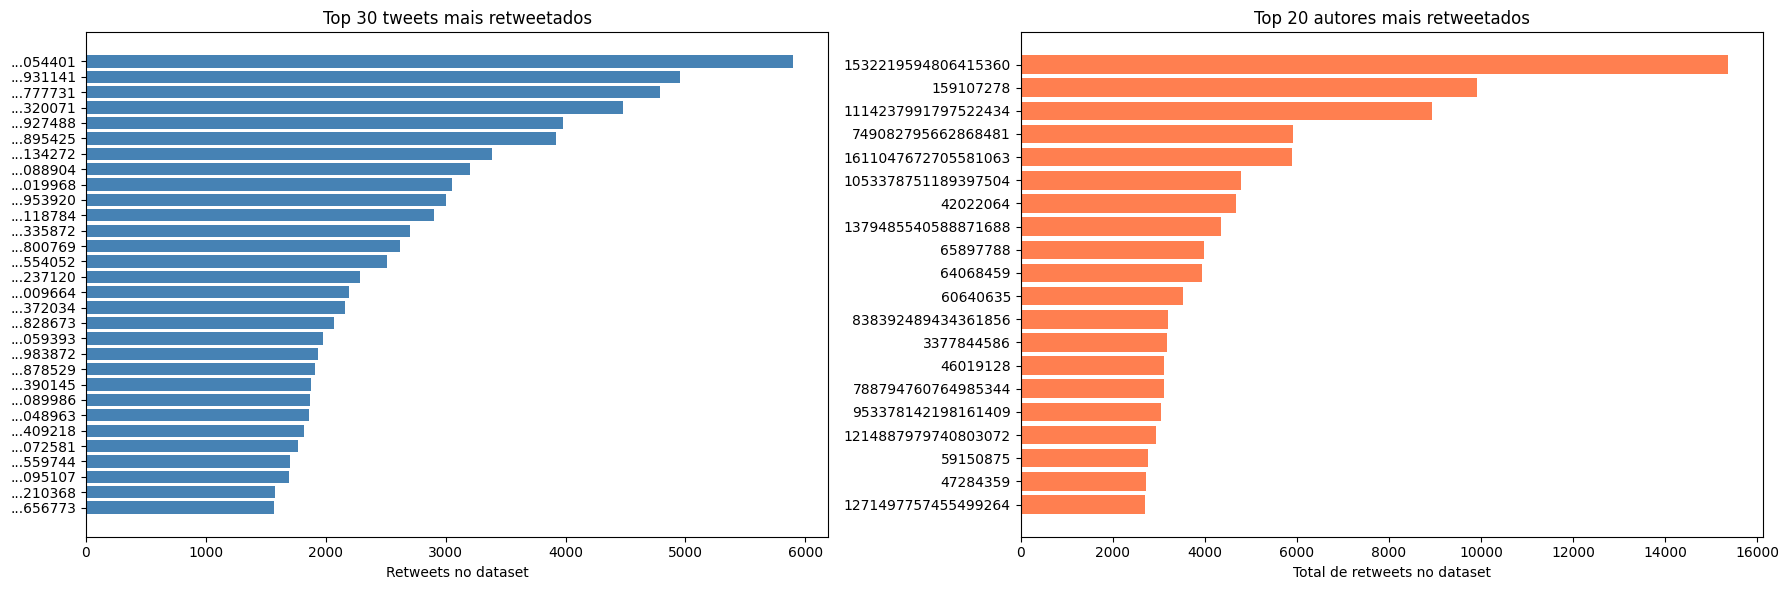

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Grafico 1: Top 30 tweets por retweet count no dataset
top30 = top100.head(30)
axes[0].barh(
    [f"...{cid[-6:]}" for cid in top30["conversation_id"]],
    top30["retweet_count_dataset"],
    color="steelblue"
)
axes[0].set_xlabel("Retweets no dataset")
axes[0].set_title("Top 30 tweets mais retweetados")
axes[0].invert_yaxis()

# Grafico 2: Top 20 autores mais retweetados (soma de RTs de todos os seus tweets)
author_rt = top_retweeted.groupby("author_id")["retweet_count_dataset"].sum()
author_rt_top20 = author_rt.sort_values(ascending=False).head(20)

axes[1].barh(
    [str(aid) for aid in author_rt_top20.index],
    author_rt_top20.values,
    color="coral"
)
axes[1].set_xlabel("Total de retweets no dataset")
axes[1].set_title("Top 20 autores mais retweetados")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

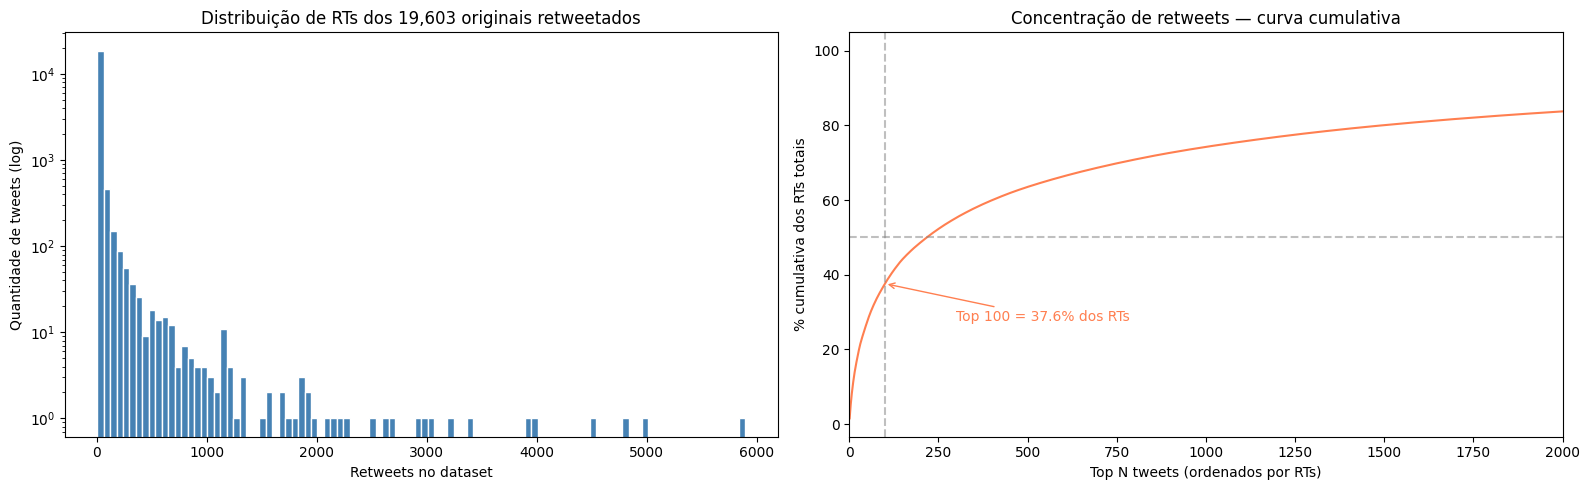

In [ ]:
# Distribuicao: quantos RTs a cauda longa dos originais tem?
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma de retweet counts (escala log para ver a cauda)
rt_nonzero = top_retweeted[top_retweeted["retweet_count_dataset"] > 0]["retweet_count_dataset"]
axes[0].hist(rt_nonzero, bins=100, color="steelblue", edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_xlabel("Retweets no dataset")
axes[0].set_ylabel("Quantidade de tweets (log)")
axes[0].set_title(f"Distribuição de RTs dos {len(rt_nonzero):,} originais retweetados")

# Curva cumulativa: % dos RTs capturados pelo top N tweets
cumulative = top_retweeted["retweet_count_dataset"].cumsum()
total_rts = top_retweeted["retweet_count_dataset"].sum()
cumulative_pct = cumulative / total_rts * 100

axes[1].plot(range(1, len(cumulative_pct) + 1), cumulative_pct, color="coral")
axes[1].axhline(y=50, color="gray", linestyle="--", alpha=0.5)
axes[1].axvline(x=100, color="gray", linestyle="--", alpha=0.5)
axes[1].set_xlim(0, 2000)
axes[1].set_xlabel("Top N tweets (ordenados por RTs)")
axes[1].set_ylabel("% cumulativa dos RTs totais")
axes[1].set_title("Concentração de retweets — curva cumulativa")

# Anotar o % atingido pelo top 100
pct_top100 = cumulative_pct.iloc[99] if len(cumulative_pct) >= 100 else cumulative_pct.iloc[-1]
axes[1].annotate(f"Top 100 = {pct_top100:.1f}% dos RTs", xy=(100, pct_top100),
                 xytext=(300, pct_top100 - 10), fontsize=10,
                 arrowprops=dict(arrowstyle="->", color="coral"), color="coral")

plt.tight_layout()
plt.show()

## Estimativa de custo para hidratação seletiva

In [ ]:
from fetch_x_data import estimate_cost

# Cenario: hidratar top 100 tweets + seus autores unicos
top100_tweet_ids = top100["conversation_id"].tolist()
top100_author_ids = top100["author_id"].tolist()

print("=== Cenario: Top 100 tweets mais retweetados ===")
est100 = estimate_cost(top100_tweet_ids, top100_author_ids)

print()

# Cenario: hidratar top 500
top500 = top_retweeted.head(500)
print("=== Cenario: Top 500 tweets mais retweetados ===")
est500 = estimate_cost(top500["conversation_id"].tolist(), top500["author_id"].tolist())

print()

# Cenario: hidratar top 1000
top1000 = top_retweeted.head(1000)
print("=== Cenario: Top 1000 tweets mais retweetados ===")
est1000 = estimate_cost(top1000["conversation_id"].tolist(), top1000["author_id"].tolist())

print(f"\n{'='*50}")
print(f"Orcamento disponivel: $5.00")
print(f"Top 100:  ${est100['total_cost_usd']:.2f}  — sobram ${5 - est100['total_cost_usd']:.2f}")
print(f"Top 500:  ${est500['total_cost_usd']:.2f}  — sobram ${5 - est500['total_cost_usd']:.2f}")
print(f"Top 1000: ${est1000['total_cost_usd']:.2f} — sobram ${5 - est1000['total_cost_usd']:.2f}")

=== Cenario: Top 100 tweets mais retweetados ===
=== Estimativa de custo ===
Tweets: 100 unicos → 1 batches → $0.50
Users:  88 unicos → 1 batches → $0.88
Total:  $1.38
Tempo estimado: ~0 min (2s com 1s/batch)

=== Cenario: Top 500 tweets mais retweetados ===
=== Estimativa de custo ===
Tweets: 500 unicos → 5 batches → $2.50
Users:  347 unicos → 4 batches → $3.47
Total:  $5.97
Tempo estimado: ~0 min (9s com 1s/batch)

=== Cenario: Top 1000 tweets mais retweetados ===
=== Estimativa de custo ===
Tweets: 1,000 unicos → 10 batches → $5.00
Users:  635 unicos → 7 batches → $6.35
Total:  $11.35
Tempo estimado: ~0 min (17s com 1s/batch)

Orcamento disponivel: $5.00
Top 100:  $1.38  — sobram $3.62
Top 500:  $5.97  — sobram $-0.97
Top 1000: $11.35 — sobram $-6.35


In [ ]:
# Quantos tweets da para hidratar com $5.00?
# Custo por tweet = $0.005, custo por user = $0.010
# Pior caso: cada tweet tem autor unico → $0.005 + $0.010 = $0.015/tweet → 333 tweets
# Melhor caso: poucos autores → custo converge pra $0.005/tweet → 1000 tweets

budget = 5.00
scenarios = [100, 250, 500, 750, 1000]
print(f"{'Top N':>8} | {'Tweets':>8} | {'Autores':>8} | {'Custo':>10} | {'Dentro do budget?':>18}")
print("-" * 70)
for n in scenarios:
    top_n = top_retweeted.head(n)
    t = len(top_n["conversation_id"].unique())
    u = len(top_n["author_id"].unique())
    cost = t * 0.005 + u * 0.010
    ok = "SIM" if cost <= budget else "NAO"
    print(f"{n:>8} | {t:>8} | {u:>8} | ${cost:>8.2f} | {ok:>18}")

   Top N |   Tweets |  Autores |      Custo |  Dentro do budget?
----------------------------------------------------------------------
     100 |      100 |       88 | $    1.38 |                SIM
     250 |      250 |      189 | $    3.14 |                SIM
     500 |      500 |      347 | $    5.97 |                NAO
     750 |      750 |      498 | $    8.73 |                NAO
    1000 |     1000 |      635 | $   11.35 |                NAO


## Estratégia 50+50: tweets mais retweetados gerais vs. originais do dataset

Os tweets mais retweetados **no geral** (cell 12) são diferentes dos originais mais retweetados (cell 13). O top geral tem tweets com 22.976 RTs que nem estão no nosso conjunto de originais — provavelmente tweets de figuras públicas, jornalistas ou políticos feitos antes/fora da janela de coleta.

**Estratégia:**
- **50 tweets mais retweetados gerais** — os tweets que mais repercutiram, independente de estarem no dataset como originais
- **50 tweets mais retweetados dos originais** — tweets autorais feitos durante o evento e presentes no nosso dataset
- Sem sobreposição entre os dois grupos

In [ ]:
# Top 50 tweets mais retweetados GERAIS (podem ou nao estar nos originais)
top50_geral = retweet_counts.head(50).copy()

# Marcar quais estao nos originais do dataset
original_ids = set(original_tweets["conversation_id"].astype(str))
top50_geral["presente_no_dataset"] = top50_geral["conversation_id"].isin(original_ids)

print(f"=== Top 50 mais retweetados GERAIS ===")
print(f"Presentes nos originais do dataset: {top50_geral['presente_no_dataset'].sum()}")
print(f"NAO presentes (externos): {(~top50_geral['presente_no_dataset']).sum()}")
print(f"RTs somados: {top50_geral['retweet_count_dataset'].sum():,}")
print()
top50_geral.head(15)

=== Top 50 mais retweetados GERAIS ===
Presentes nos originais do dataset: 10
NAO presentes (externos): 40
RTs somados: 325,988



,conversation_id,retweet_count_dataset,presente_no_dataset
0,1612165918230188034,22976,False
1,1612191803901444098,21092,False
2,1612164676145610757,19208,False
3,1612169657154256901,17996,False
4,1612193089095073793,13793,False
5,1612213096512094209,12160,False
6,1612160869533732865,11802,False
7,1612192617260777480,10501,False
8,1612174941834645505,9810,False
9,1612226342019338240,9390,False


In [ ]:
# Top 50 originais mais retweetados, EXCLUINDO os que ja estao no top 50 geral
top50_geral_ids = set(top50_geral["conversation_id"])
top50_originais = top_retweeted[~top_retweeted["conversation_id"].isin(top50_geral_ids)].head(50).copy()

print(f"=== Top 50 mais retweetados ORIGINAIS (sem sobreposição) ===")
print(f"RTs somados: {top50_originais['retweet_count_dataset'].sum():,}")
print(f"Autores unicos: {top50_originais['author_id'].nunique()}")
print()
top50_originais[["conversation_id", "author_id", "retweet_count_dataset", "Created_at_convert"]].head(15)

=== Top 50 mais retweetados ORIGINAIS (sem sobreposição) ===
RTs somados: 75,408
Autores unicos: 44



,conversation_id,author_id,retweet_count_dataset,Created_at_convert
10,1612131005376118784,42022064,2906,2023-01-08 13:55:58-03:00
11,1612178336704335872,1114237991797522434,2700,2023-01-08 17:04:02-03:00
12,1612215570656800769,1508101517009727488,2620,2023-01-08 19:32:00-03:00
13,1612171566967554052,47284359,2510,2023-01-08 16:37:08-03:00
14,1612167421263237120,3374355814,2286,2023-01-08 16:20:40-03:00
15,1612167584929009664,391650906,2192,2023-01-08 16:21:19-03:00
16,1612166460595372034,941526010297757696,2161,2023-01-08 16:16:51-03:00
17,1612190413644828673,24511456,2072,2023-01-08 17:52:02-03:00
18,1612224029280059393,4060086012,1979,2023-01-08 20:05:36-03:00
19,1612207317851983872,1075036110,1938,2023-01-08 18:59:12-03:00


In [ ]:
# Conjunto final: 50 gerais + 50 originais (sem duplicata)
all_tweet_ids = list(top50_geral["conversation_id"]) + list(top50_originais["conversation_id"])
all_tweet_ids = list(dict.fromkeys(all_tweet_ids))  # preserva ordem, remove duplicatas

# Para os autores: os gerais nao tem author_id no retweet_counts (so temos o tweet id).
# Precisamos hidratar os tweets primeiro e extrair author_id do retorno da API.
# Ja os originais tem author_id no dataset.
author_ids_originais = list(top50_originais["author_id"].unique())

# Para os top 50 gerais que JA estao nos originais, podemos pegar o author_id
gerais_no_dataset = top50_geral[top50_geral["presente_no_dataset"]]
if len(gerais_no_dataset) > 0:
    author_ids_gerais_conhecidos = original_tweets[
        original_tweets["conversation_id"].isin(gerais_no_dataset["conversation_id"])
    ]["author_id"].unique().tolist()
else:
    author_ids_gerais_conhecidos = []

# Autores que ja conhecemos (dos originais + gerais presentes no dataset)
known_author_ids = list(set(author_ids_originais + author_ids_gerais_conhecidos))

# Autores desconhecidos (gerais que nao estao no dataset) — virao da hidratacao dos tweets
gerais_externos = top50_geral[~top50_geral["presente_no_dataset"]]

print(f"=== Conjunto final para hidratação ===")
print(f"Tweets a hidratar: {len(all_tweet_ids)}")
print(f"  - Top 50 gerais: {len(top50_geral)}")
print(f"  - Top 50 originais (sem overlap): {len(top50_originais)}")
print(f"Autores ja conhecidos (do dataset): {len(known_author_ids)}")
print(f"Autores desconhecidos (gerais externos): {len(gerais_externos)} (author_id vira com a hidratacao)")
print(f"\n--- Estimativa de custo (pior caso) ---")

# Tweets: sempre pagamos
tweet_cost = len(all_tweet_ids) * 0.005
# Users: conhecidos + estimativa dos externos (1 autor por tweet externo no pior caso)
max_users = len(known_author_ids) + len(gerais_externos)
user_cost = max_users * 0.010
total = tweet_cost + user_cost

print(f"Tweets: {len(all_tweet_ids)} x $0.005 = ${tweet_cost:.2f}")
print(f"Users:  {max_users} x $0.010 = ${user_cost:.2f}  (pior caso)")
print(f"Total estimado: ${total:.2f}")
print(f"Sobram do budget ($5): ${5 - total:.2f}")

=== Conjunto final para hidratação ===
Tweets a hidratar: 100
  - Top 50 gerais: 50
  - Top 50 originais (sem overlap): 50
Autores ja conhecidos (do dataset): 54
Autores desconhecidos (gerais externos): 40 (author_id vira com a hidratacao)

--- Estimativa de custo (pior caso) ---
Tweets: 100 x $0.005 = $0.50
Users:  94 x $0.010 = $0.94  (pior caso)
Total estimado: $1.44
Sobram do budget ($5): $3.56


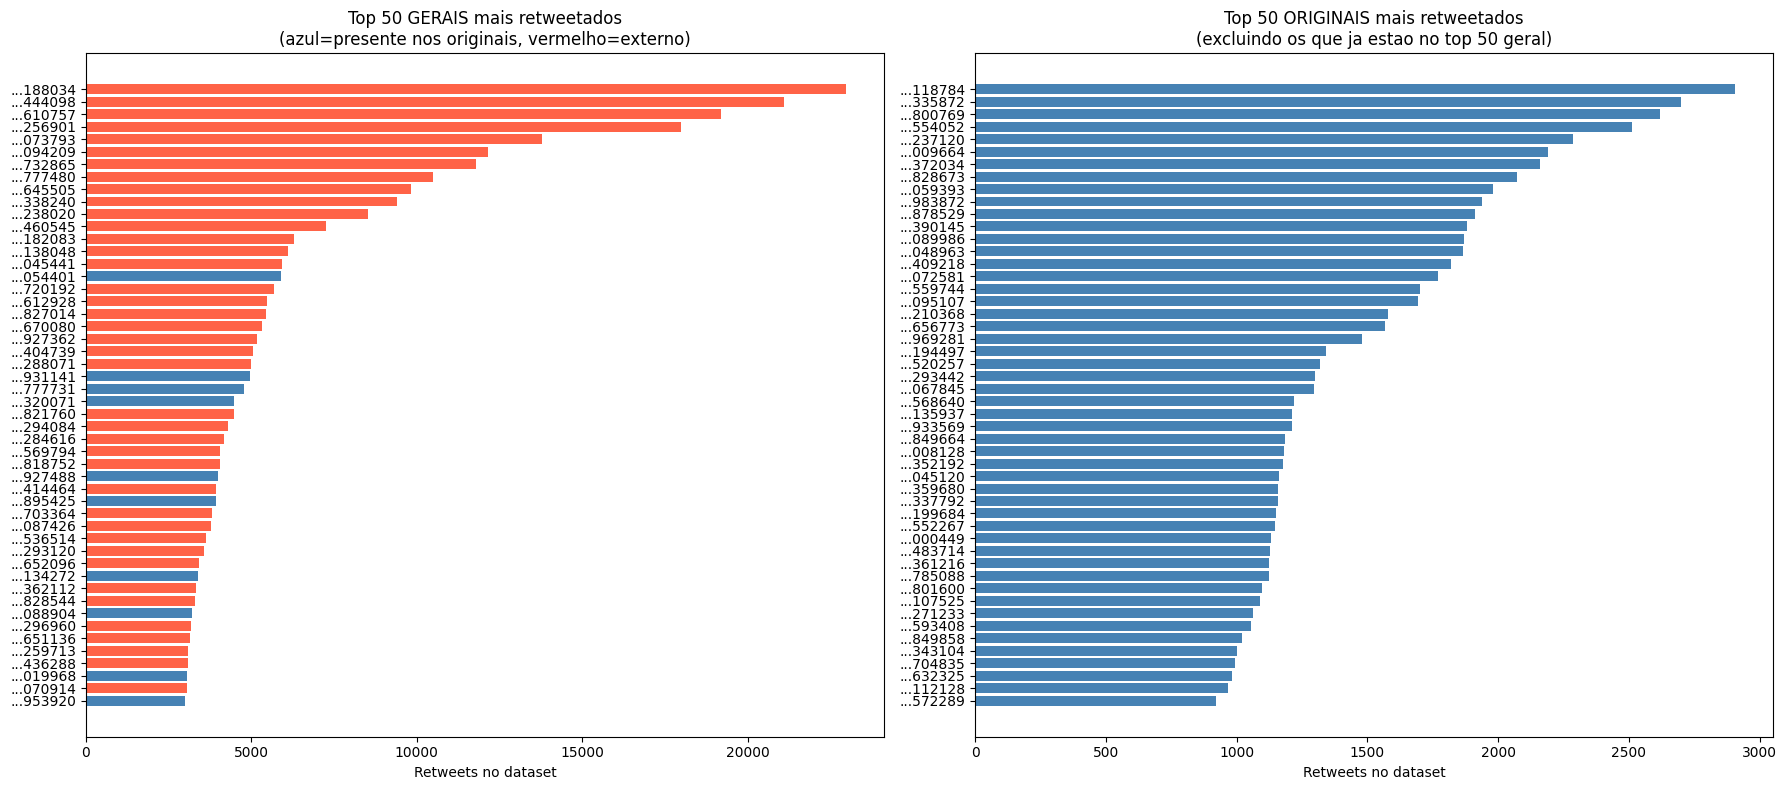


Cobertura combinada (50+50):
  401,396 / 1,100,026 retweets = 36.5% do dataset


In [ ]:
# Visualizacao comparativa: top 50 gerais vs top 50 originais
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top 50 gerais
colors_geral = ["steelblue" if p else "tomato" for p in top50_geral["presente_no_dataset"]]
axes[0].barh(
    [f"...{cid[-6:]}" for cid in top50_geral["conversation_id"]],
    top50_geral["retweet_count_dataset"],
    color=colors_geral
)
axes[0].set_xlabel("Retweets no dataset")
axes[0].set_title("Top 50 GERAIS mais retweetados\n(azul=presente nos originais, vermelho=externo)")
axes[0].invert_yaxis()

# Top 50 originais (sem overlap)
axes[1].barh(
    [f"...{cid[-6:]}" for cid in top50_originais["conversation_id"]],
    top50_originais["retweet_count_dataset"],
    color="steelblue"
)
axes[1].set_xlabel("Retweets no dataset")
axes[1].set_title("Top 50 ORIGINAIS mais retweetados\n(excluindo os que ja estao no top 50 geral)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nCobertura combinada (50+50):")
total_rts_dataset = retweets.shape[0]
rts_cobertos = top50_geral["retweet_count_dataset"].sum() + top50_originais["retweet_count_dataset"].sum()
print(f"  {rts_cobertos:,} / {total_rts_dataset:,} retweets = {rts_cobertos/total_rts_dataset:.1%} do dataset")

## Hidratação via API do X

### Teste: buscar 1 tweet para validar a API e ver a estrutura de retorno

In [ ]:
import json
from fetch_x_data import fetch_tweets_batch

# Buscar apenas o 1o tweet do nosso conjunto (custo: $0.005)
test_id = all_tweet_ids[0]
print(f"Buscando tweet de teste: {test_id}")

test_result = fetch_tweets_batch([test_id])

# Salvar resultado bruto para referencia
with open("test_tweet.json", "w", encoding="utf-8") as f:
    json.dump(test_result, f, ensure_ascii=False, indent=2)

print(f"\nStatus: {'OK' if test_result and test_result.get('data') else 'FALHA'}")
print(f"Arquivo salvo: test_tweet.json")
print(f"\n--- Conteudo retornado ---")
print(json.dumps(test_result, ensure_ascii=False, indent=2))

Buscando tweet de teste: 1612165918230188034

Status: FALHA
Arquivo salvo: test_tweet.json

--- Conteudo retornado ---
{
  "errors": [
    {
      "value": "1612165918230188034",
      "detail": "Could not find tweet with ids: [1612165918230188034].",
      "title": "Not Found Error",
      "resource_type": "tweet",
      "parameter": "ids",
      "resource_id": "1612165918230188034",
      "type": "https://api.twitter.com/2/problems/resource-not-found"
    }
  ]
}


### Hidratação completa: 100 tweets (50 gerais + 50 originais)

Pipeline em 3 etapas:
1. `hydrate_tweets` — busca os 100 tweets → `hydrated_tweets.jsonl`
2. `hydrate_users` — busca autores únicos → `hydrated_users.json`
3. `merge_to_csv` — junta tudo → `hydrated_tweets.csv`

In [ ]:
# from fetch_x_data import hydrate_tweets, hydrate_users, load_hydrated_tweets, merge_to_csv

# # Etapa 1: hidratar os 100 tweets (custo: ~$0.50)
# print("=" * 50)
# print("ETAPA 1: Hidratando tweets")
# print("=" * 50)
# hydrate_tweets(all_tweet_ids)

ETAPA 1: Hidratando tweets
Tweets — Total: 100 | Ja buscados: 0 | Restantes: 100
  Custo estimado restante: $0.50 (1 batches)
  Batch 1/1 (100 IDs)...
Concluido: 83 tweets em 'hydrated_tweets.jsonl'


83

In [ ]:
# # Etapa 2: extrair author_ids dos tweets hidratados e buscar usuarios unicos
# tweets = load_hydrated_tweets()

# # Coletar todos os author_ids retornados pela API
# api_author_ids = list({tw["author_id"] for tw in tweets if "author_id" in tw})

# # Juntar com os que ja conheciamos do dataset (podem ter overlap — hydrate_users deduplica)
# all_author_ids = list(set(api_author_ids + known_author_ids))

# print(f"Author IDs vindos da API: {len(api_author_ids)}")
# print(f"Author IDs ja conhecidos do dataset: {len(known_author_ids)}")
# print(f"Author IDs unicos totais: {len(all_author_ids)}")

# print("\n" + "=" * 50)
# print("ETAPA 2: Hidratando autores")
# print("=" * 50)
# hydrate_users(all_author_ids)

Author IDs vindos da API: 66
Author IDs ja conhecidos do dataset: 54
Author IDs unicos totais: 120

ETAPA 2: Hidratando autores
Users — Total unicos: 75 | Ja buscados: 0 | Restantes: 75
  Custo estimado restante: $0.75 (1 batches)
  Batch 1/1 (75 IDs)...
Concluido: 72 usuarios em 'hydrated_users.json'


{'68313718': {'username': 'STF_oficial',
  'url': 'https://t.co/q0fcxmsao9',
  'location': 'Brasília - DF',
  'profile_image_url': 'https://pbs.twimg.com/profile_images/1726624942463004672/kipecnVb_normal.jpg',
  'protected': False,
  'id': '68313718',
  'verified_type': 'government',
  'description': 'Supremo Tribunal Federal: o #TribunaldaConstituição! A instância máxima do Poder Judiciário trabalha para garantir os seus direitos ⚖️ A Constituição é sua 📗',
  'created_at': '2009-08-24T03:21:06.000Z',
  'public_metrics': {'followers_count': 2551252,
   'following_count': 54,
   'tweet_count': 30218,
   'listed_count': 5529,
   'like_count': 623,
   'media_count': 8536},
  'entities': {'url': {'urls': [{'start': 0,
      'end': 23,
      'url': 'https://t.co/q0fcxmsao9',
      'expanded_url': 'http://bit.ly/PoliticadeRedesSTF',
      'display_url': 'bit.ly/PoliticadeRede…'}]},
   'description': {'hashtags': [{'start': 28,
      'end': 51,
      'tag': 'TribunaldaConstituição'}]}},
  'v

In [ ]:
# # Etapa 3: merge tweets + autores em CSV flat
# print("=" * 50)
# print("ETAPA 3: Gerando CSV final")
# print("=" * 50)
# merge_to_csv()

# # Visualizar resultado
# result_df = pd.read_csv("hydrated_tweets.csv")
# print(f"\nColunas: {list(result_df.columns)}")
# print(f"Linhas: {len(result_df)}")
# result_df[["tweet_id", "text", "author_username", "like_count", "retweet_count", "hashtags"]].head(10)

ETAPA 3: Gerando CSV final
CSV exportado: 'hydrated_tweets.csv' (83 linhas)

Colunas: ['tweet_id', 'text', 'created_at', 'lang', 'source', 'conversation_id', 'in_reply_to_user_id', 'possibly_sensitive', 'reply_settings', 'retweet_count', 'reply_count', 'like_count', 'quote_count', 'bookmark_count', 'impression_count', 'hashtags', 'mentions', 'urls', 'annotations', 'geo_place_id', 'author_id', 'author_name', 'author_username', 'author_description', 'author_location', 'author_created_at', 'author_verified', 'author_verified_type', 'author_protected', 'author_profile_image_url', 'author_url', 'author_followers_count', 'author_following_count', 'author_tweet_count', 'author_listed_count']
Linhas: 83


,tweet_id,text,author_username,like_count,retweet_count,hashtags
0,1612199082021294084,Que fique claro que o responsável por acionar ...,capitaotelhada,27789,6250,NaN
1,1612179300798828544,"Parágrafo único:\nQuem vier aqui passar pano, ...",carlavilhenaa,60633,4690,NaN
2,1612219829846409218,GRAVE 🚨 CNN obtém áudio de Magno Malta convoca...,GNGeekNation,23320,3831,NaN
3,1612171566967554052,"🇧🇷⚡ — More from National Congress, Brasília. h...",OnePaul87,6484,2545,NaN
4,1612162945265569794,🚨AGORA: Enquanto bolsonaristas invadem o Congr...,choquei,24281,4169,NaN
5,1612174102160199684,metade de brasília vai estar desempregada aman...,nextlevelbiel,9310,1453,NaN
6,1612173688711045120,Um policial é protegido e aplaudido pelos mani...,LinaFerruccio,3528,1152,NaN
7,1612065935208112128,Cerca de 300 ônibus chegam a Brasília nesta ma...,ATROMBETA3,3046,922,NaN
8,1612191807940460545,E vamos descobrir quem são os financiadores de...,LulaOficial,88311,7736,NaN
9,1612191803901444098,Vocês devem ter acompanhado a barbárie em Bras...,LulaOficial,270996,22958,NaN


In [ ]:
# # Top 15 tweets hidratados por retweet_count (metrica real da API)
# top15 = result_df.sort_values("retweet_count", ascending=False).head(15)

# for i, row in top15.iterrows():
#     print(f"{'='*70}")
#     print(f"@{row['author_username']}  —  {row['created_at']}")
#     print(f"RTs: {row['retweet_count']:,}  |  Likes: {row['like_count']:,}  |  Quotes: {row['quote_count']:,}  |  Replies: {row['reply_count']:,}")
#     print(f"Impressions: {row['impression_count']:,}" if pd.notna(row['impression_count']) else "Impressions: N/A")
#     print(f"Hashtags: {row['hashtags']}" if pd.notna(row['hashtags']) else "Hashtags: —")
#     print(f"\n{row['text']}")
#     print()

@thiagoooqz  —  2023-01-08T19:29:33.000Z
RTs: 28,348  |  Likes: 127,538  |  Quotes: 1,343  |  Replies: 919
Impressions: 4,021,867
Hashtags: —

bolsonaristas invadindo o congresso 

a pm de brasilia https://t.co/c2j74zs58C

@maiconkuster  —  2023-01-08T19:09:46.000Z
RTs: 27,780  |  Likes: 147,311  |  Quotes: 1,408  |  Replies: 957
Impressions: 5,144,197
Hashtags: —

o bolsonaro na disney em orlando e os corno quebrando tudo em brasilia

@LulaOficial  —  2023-01-08T20:57:33.000Z
RTs: 22,958  |  Likes: 270,996  |  Quotes: 2,005  |  Replies: 17,646
Impressions: 11,355,567
Hashtags: —

Vocês devem ter acompanhado a barbárie em Brasília hoje. Aquelas pessoas que chamamos de fascistas, o que há de mais abominável na política, invadiram a sede do palácio e o Congresso. Achamos que houve falta de segurança.

@nandaxxie  —  2023-01-09T00:53:15.000Z
RTs: 21,549  |  Likes: 110,313  |  Quotes: 7,458  |  Replies: 893
Impressions: 7,737,158
Hashtags: —

Obras de arte que foram DESTRUÍDAS ou ROUBADAS 

## Amostra dos tweets ORIGINAIS hidratados (ordenados por retweets)

Distinção entre os dois grupos no `hydrated_tweets.csv`: um tweet pertence ao grupo **originais** se seu `tweet_id` aparece como `conversation_id` em `original_tweets.csv` (ou seja, foi coletado como tweet autoral durante a janela do evento). Os demais são do grupo **gerais** — tweets externos ao dataset que apareceram apenas como retweets/quotes.

Abaixo classificamos cada tweet hidratado e mostramos uma amostra do grupo **originais** ordenada por `retweet_count` (métrica real da API).

In [11]:
import pandas as pd

# Classificar cada tweet hidratado como "originais" ou "gerais"
hydrated = pd.read_csv("hydrated_tweets.csv")
hydrated["tweet_id"] = hydrated["tweet_id"].astype(str)

original_ids_set = set(pd.read_csv("original_tweets.csv")["conversation_id"].astype(str))
hydrated["grupo"] = hydrated["tweet_id"].apply(
    lambda tid: "originais" if tid in original_ids_set else "gerais"
)

print(f"Distribuicao por grupo no hydrated_tweets.csv:")
print(hydrated["grupo"].value_counts())
print()

# Amostra dos originais ordenados por RTs
originais_hyd = hydrated[hydrated["grupo"] == "originais"].sort_values(
    "retweet_count", ascending=False
).reset_index(drop=True)

print(f"=== Top {len(originais_hyd)} tweets ORIGINAIS hidratados (por retweet_count) ===\n")
for _, row in originais_hyd.iterrows():
    print("=" * 70)
    print(f"@{row['author_username']}  —  {row['created_at']}")
    print(f"RTs: {row['retweet_count']:,}  |  Likes: {row['like_count']:,}  |  Quotes: {row['quote_count']:,}  |  Replies: {row['reply_count']:,}")
    print(f"\n{row['text']}\n")


Distribuicao por grupo no hydrated_tweets.csv:
grupo
originais    50
gerais       33
Name: count, dtype: int64

=== Top 50 tweets ORIGINAIS hidratados (por retweet_count) ===

@nandaxxie  —  2023-01-09T00:53:15.000Z
RTs: 21,549  |  Likes: 110,313  |  Quotes: 7,458  |  Replies: 893

Obras de arte que foram DESTRUÍDAS ou ROUBADAS por bolsonaristas em Brasília durante a invasão; UMA THREAD https://t.co/yshsDtbsGu

@Oparbento1  —  2023-01-08T22:53:44.000Z
RTs: 6,257  |  Likes: 27,806  |  Quotes: 137  |  Replies: 183

Quando Dilma sofreu golpe, não teve quebradeira.
Quando Lula foi preso, não teve quebradeira.
Quando Haddad perdeu a eleição, não teve quebradeira.
"Ah mas o PT". "Ah mas o PT é o caralho".
Anistia é o caralho.
#brasilia

@adilsonesp  —  2023-01-08T23:05:23.000Z
RTs: 6,187  |  Likes: 8,344  |  Quotes: 439  |  Replies: 235

FOI TUDO PLANEJADO! Ajudem a divulgar os infiltrados! Senão nós vamos perder a batalha! São eles em Brasilia e nós nas redes sociais! Ajudem! https://t.co/m

In [12]:
# Persistir a coluna "grupo" no CSV para uso em analises futuras
hydrated.to_csv("hydrated_tweets.csv", index=False)
print("Coluna 'grupo' adicionada ao hydrated_tweets.csv")
print(hydrated[["tweet_id", "author_username", "retweet_count", "grupo"]].head())


Coluna 'grupo' adicionada ao hydrated_tweets.csv
              tweet_id author_username  retweet_count      grupo
0  1612199082021294084  capitaotelhada           6250     gerais
1  1612179300798828544   carlavilhenaa           4690     gerais
2  1612219829846409218    GNGeekNation           3831  originais
3  1612171566967554052       OnePaul87           2545  originais
4  1612162945265569794         choquei           4169     gerais
